In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
DATA_DIR = "/Volumes/Tejas SSD/sepsis-sentinel/data/raw"
PROJECT_DIR = "/Volumes/Tejas SSD/sepsis-sentinel"

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Imports OK")

Imports OK


In [2]:
import sys
sys.path.insert(0, PROJECT_DIR)
from src.data.mimic_loader import load_cohort

cohort = load_cohort(DATA_DIR)
print(f"Shape: {cohort.shape}")
cohort.head()

Loading icustays...
Loading admissions...
Loading patients...
Loading diagnoses_icd...
Cohort built: 65,366 ICU stays (9,433 sepsis-positive)
Shape: (65366, 10)


,subject_id,hadm_id,stay_id,gender,anchor_age,admittime,icu_intime,icu_outtime,los_icu_hours,sepsis_label
0,18106347,24305596,30588857,F,48,2110-01-11 10:14:00,2110-01-11 10:16:06,2110-01-12 17:17:47,31.028056,0
1,17195991,23542772,38319097,F,61,2110-01-11 22:47:00,2110-01-12 00:54:00,2110-01-14 22:07:39,69.227500,0
2,16284044,23864737,36817845,F,61,2110-01-11 19:58:00,2110-01-13 09:09:40,2110-01-15 21:45:33,60.598056,0
3,18122666,23883987,39753527,M,60,2110-01-14 05:17:00,2110-01-14 07:22:00,2110-01-15 13:08:36,29.776667,0
4,15463892,29280967,30471766,M,83,2110-01-14 18:06:00,2110-01-14 18:07:20,2110-01-19 17:39:09,119.530278,0


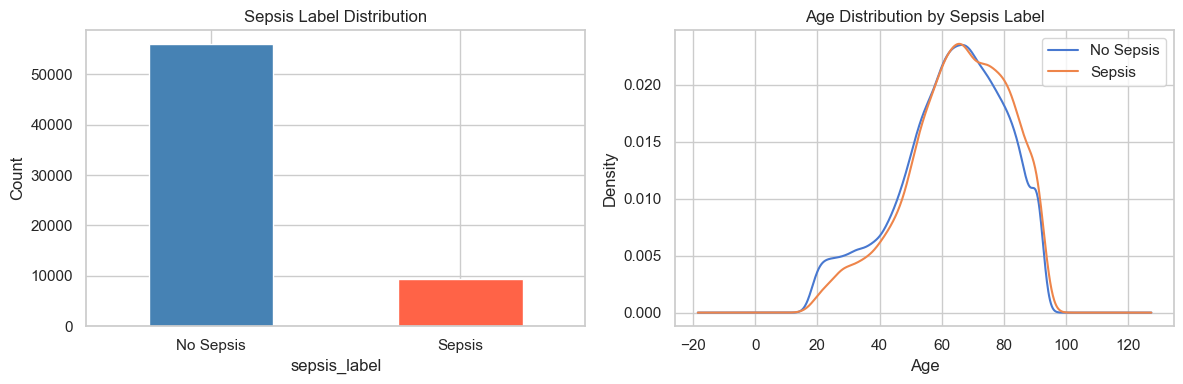

Sepsis rate: 14.4%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
cohort['sepsis_label'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato']
)
axes[0].set_title("Sepsis Label Distribution")
axes[0].set_xticklabels(['No Sepsis', 'Sepsis'], rotation=0)
axes[0].set_ylabel("Count")

# Age by sepsis label
cohort.groupby('sepsis_label')['anchor_age'].plot(
    kind='kde', ax=axes[1], legend=True
)
axes[1].set_title("Age Distribution by Sepsis Label")
axes[1].set_xlabel("Age")
axes[1].legend(['No Sepsis', 'Sepsis'])

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/reports/figures/eda_prevalence.png", dpi=150)
plt.show()
print(f"Sepsis rate: {cohort['sepsis_label'].mean():.1%}")

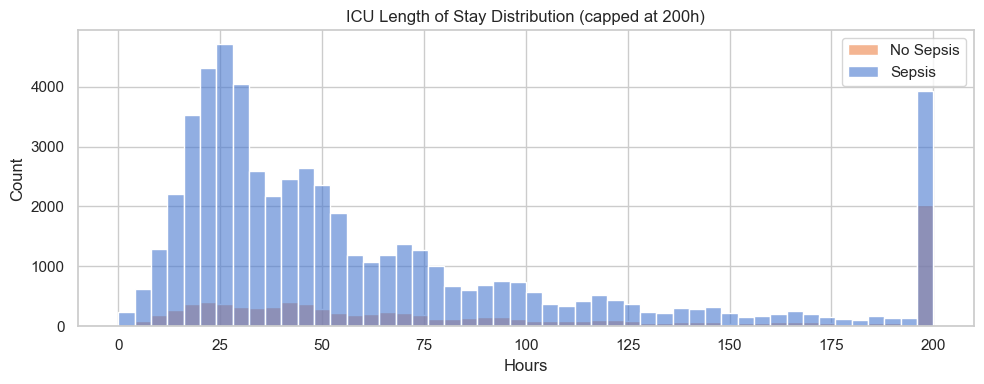

LOS stats by label:
                count   mean    std  min   25%   50%    75%     max
sepsis_label                                                       
0             55928.0   74.3  102.2  0.0  25.6  43.7   79.3  3832.0
1              9426.0  145.5  205.8  0.4  36.2  70.2  168.9  3361.3


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

# Cap at 200 hours for readability (long tail)
los_capped = cohort['los_icu_hours'].clip(upper=200)
sns.histplot(data=cohort, x=los_capped, hue='sepsis_label', 
             bins=50, ax=ax, alpha=0.6)
ax.set_title("ICU Length of Stay Distribution (capped at 200h)")
ax.set_xlabel("Hours")
ax.legend(['No Sepsis', 'Sepsis'])

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/reports/figures/eda_los.png", dpi=150)
plt.show()

print("LOS stats by label:")
print(cohort.groupby('sepsis_label')['los_icu_hours'].describe().round(1))

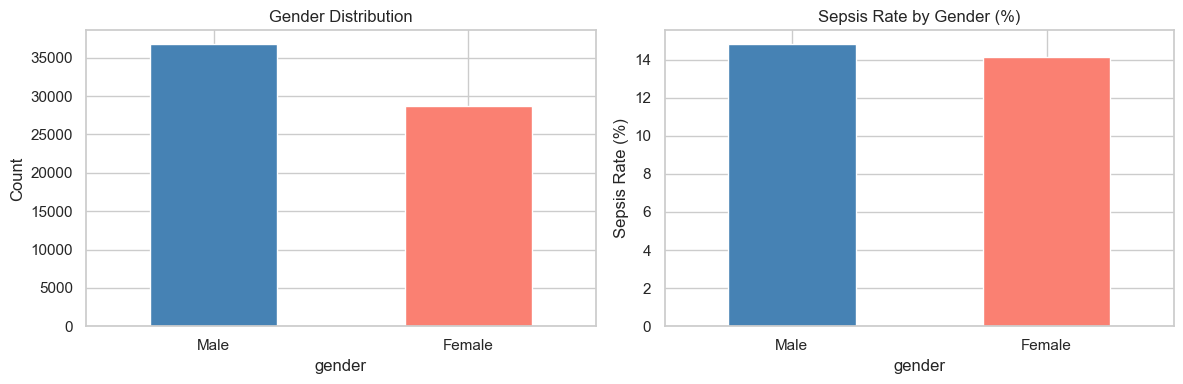

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gender overall
cohort['gender'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon']
)
axes[0].set_title("Gender Distribution")
axes[0].set_xticklabels(['Male', 'Female'], rotation=0)
axes[0].set_ylabel("Count")

# Sepsis rate by gender
sepsis_by_gender = cohort.groupby('gender')['sepsis_label'].mean() * 100
sepsis_by_gender.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title("Sepsis Rate by Gender (%)")
axes[1].set_xticklabels(['Male', 'Female'], rotation=0)
axes[1].set_ylabel("Sepsis Rate (%)")

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/reports/figures/eda_gender.png", dpi=150)
plt.show()

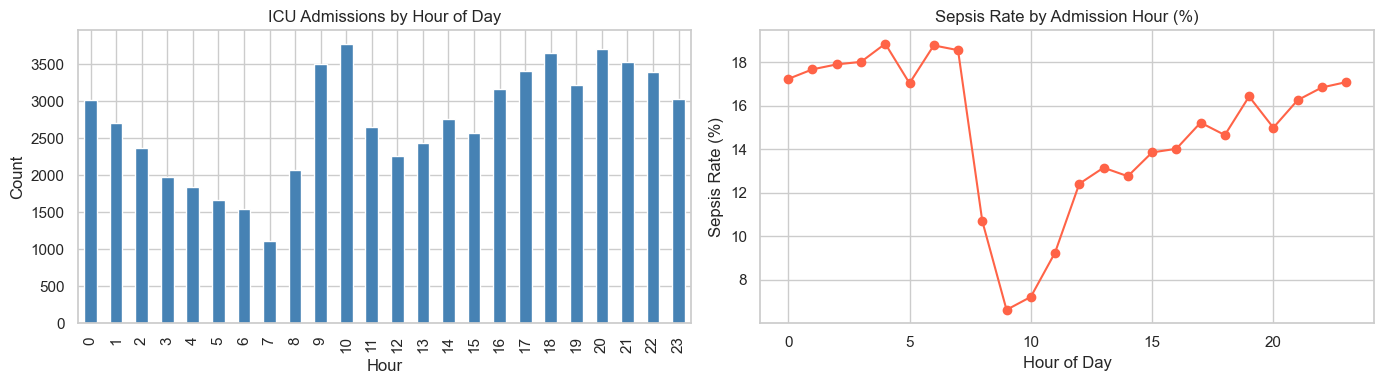

In [6]:
# Hour of ICU admission — does time of day affect sepsis rate?
cohort['admit_hour'] = cohort['icu_intime'].dt.hour
cohort['admit_dow']  = cohort['icu_intime'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Admissions by hour
cohort['admit_hour'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title("ICU Admissions by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count")

# Sepsis rate by hour
sepsis_by_hour = cohort.groupby('admit_hour')['sepsis_label'].mean() * 100
sepsis_by_hour.plot(kind='line', ax=axes[1], marker='o', color='tomato')
axes[1].set_title("Sepsis Rate by Admission Hour (%)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Sepsis Rate (%)")

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/reports/figures/eda_admission_patterns.png", dpi=150)
plt.show()

In [7]:
print("=" * 50)
print("COHORT SUMMARY — MIMIC-IV v3.1")
print("=" * 50)
print(f"Total ICU stays:        {len(cohort):,}")
print(f"Unique patients:        {cohort['subject_id'].nunique():,}")
print(f"Sepsis positive:        {cohort['sepsis_label'].sum():,} ({cohort['sepsis_label'].mean():.1%})")
print(f"Median age:             {cohort['anchor_age'].median():.0f} years")
print(f"Age range:              {cohort['anchor_age'].min():.0f} – {cohort['anchor_age'].max():.0f}")
print(f"Median ICU LOS:         {cohort['los_icu_hours'].median():.1f} hours")
print(f"Gender (M/F):           {(cohort['gender']=='M').sum():,} / {(cohort['gender']=='F').sum():,}")
print("=" * 50)

COHORT SUMMARY — MIMIC-IV v3.1
Total ICU stays:        65,366
Unique patients:        65,366
Sepsis positive:        9,433 (14.4%)
Median age:             65 years
Age range:              18 – 91
Median ICU LOS:         45.9 hours
Gender (M/F):           36,720 / 28,646


In [8]:
from src.data.mimic_loader import load_vitals

# Use only first 1000 stays to keep it fast
sample_ids = cohort['stay_id'].tolist()[:1000]

print("Loading vitals for 1000 stays...")
vitals = load_vitals(DATA_DIR, sample_ids)
print(f"Vitals shape: {vitals.shape}")
print(f"Itemids present: {vitals['itemid'].unique()}")
print(f"Date range: {vitals['charttime'].min()} → {vitals['charttime'].max()}")
print(f"\nMeasurements per itemid:")
print(vitals['itemid'].value_counts())

Loading vitals for 1000 stays...
Loading chartevents in chunks (this may take a few minutes)...
  ...processed 5,000,000 rows so far
  ...processed 10,000,000 rows so far
  ...processed 15,000,000 rows so far
  ...processed 20,000,000 rows so far
  ...processed 25,000,000 rows so far
  ...processed 30,000,000 rows so far
  ...processed 35,000,000 rows so far
  ...processed 40,000,000 rows so far
  ...processed 45,000,000 rows so far
  ...processed 50,000,000 rows so far
  ...processed 55,000,000 rows so far
  ...processed 60,000,000 rows so far
  ...processed 65,000,000 rows so far
  ...processed 70,000,000 rows so far
  ...processed 75,000,000 rows so far
  ...processed 80,000,000 rows so far
  ...processed 85,000,000 rows so far
  ...processed 90,000,000 rows so far
  ...processed 95,000,000 rows so far
  ...processed 100,000,000 rows so far
  ...processed 105,000,000 rows so far
  ...processed 110,000,000 rows so far
  ...processed 115,000,000 rows so far
  ...processed 120,000,000 

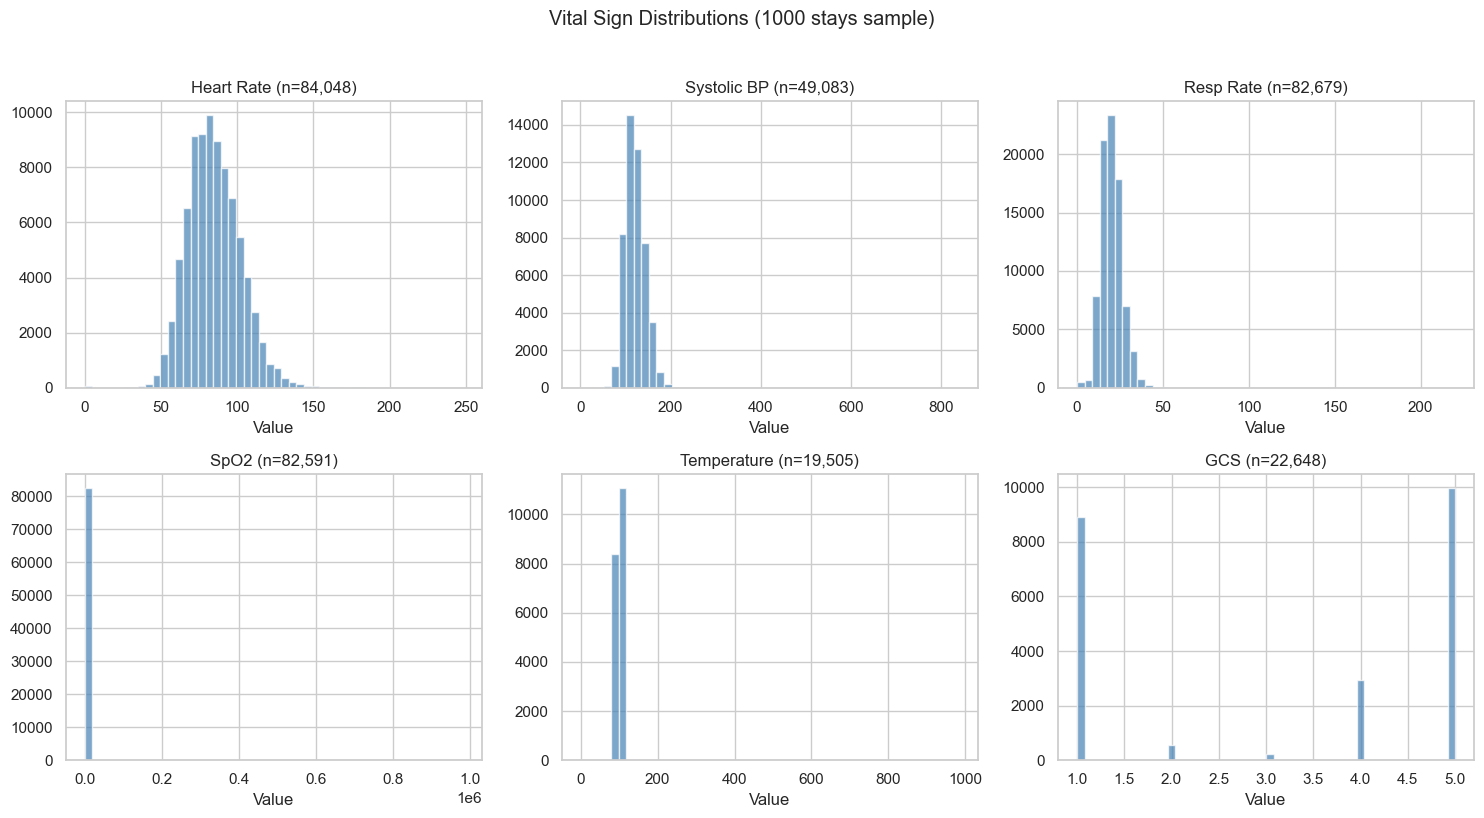

In [9]:
itemid_names = {
    220045: 'Heart Rate',
    220179: 'Systolic BP', 
    220210: 'Resp Rate',
    220277: 'SpO2',
    223761: 'Temperature',
    223900: 'GCS'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (iid, name) in enumerate(itemid_names.items()):
    data = vitals[vitals['itemid'] == iid]['valuenum']
    axes[i].hist(data, bins=50, color='steelblue', alpha=0.7)
    axes[i].set_title(f"{name} (n={len(data):,})")
    axes[i].set_xlabel("Value")

plt.suptitle("Vital Sign Distributions (1000 stays sample)", y=1.02)
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/reports/figures/eda_vitals.png", dpi=150)
plt.show()

In [10]:
# Define physiologically plausible ranges per itemid
valid_ranges = {
    220045: (20, 300),      # Heart rate: 20-300 bpm
    220179: (40, 300),      # Systolic BP: 40-300 mmHg
    220210: (4, 60),        # Resp rate: 4-60 breaths/min
    220277: (50, 100),      # SpO2: 50-100%
    223761: (95, 107),      # Temperature: 95-107 °F
    223900: (1, 15),        # GCS total: 1-15
}

before = len(vitals)
cleaned_frames = []
for iid, (lo, hi) in valid_ranges.items():
    subset = vitals[vitals['itemid'] == iid]
    cleaned = subset[(subset['valuenum'] >= lo) & (subset['valuenum'] <= hi)]
    pct_dropped = (1 - len(cleaned)/len(subset)) * 100
    print(f"itemid {iid}: kept {len(cleaned):,}/{len(subset):,} ({pct_dropped:.1f}% dropped)")
    cleaned_frames.append(cleaned)

vitals_clean = pd.concat(cleaned_frames, ignore_index=True)
print(f"\nTotal: {before:,} → {len(vitals_clean):,} rows ({(1-len(vitals_clean)/before)*100:.1f}% dropped)")

itemid 220045: kept 83,991/84,048 (0.1% dropped)
itemid 220179: kept 49,080/49,083 (0.0% dropped)
itemid 220210: kept 82,191/82,679 (0.6% dropped)
itemid 220277: kept 82,545/82,591 (0.1% dropped)
itemid 223761: kept 19,449/19,505 (0.3% dropped)
itemid 223900: kept 22,648/22,648 (0.0% dropped)

Total: 340,554 → 339,904 rows (0.2% dropped)
